In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

# Homework on Novelty Detection

----------------------------------------------------
Machine Learning                      

*Emilio Parrado Hernández, eparrado@ing.uc3m.es*

*Vanessa Gómez Verdejo vanessag@ing.uc3m.es*

----------------------------------------------------

In this practice you will analyze the use of novelty detection in a classification problem using MNIST database for digit recognition.

To solve this notebook, complete the following sections implementing the solution that you consider most appropriate and showing the results that you find most interesting.


## 1. Data loading and preprocessing

The following cell reproduces part of the code we used to download and plot some of the images during the homework. Feel free to use as it is.


In [2]:
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    # Legacy Python that doesn't verify HTTPS certificates by default
    pass
else:
    # Handle target environment that doesn't support HTTPS verification
    ssl._create_default_https_context = _create_unverified_https_context

import pandas as pd

url = 'http://www.tsc.uc3m.es/~vanessa/data_notebooks/mnist/mnist_test.csv'
df = pd.read_csv(url)

# Use the first column as labels (Y)
Y = df.iloc[:, 0].values

# Use the remaining columns as data (X)
X = df.iloc[:, 1:].values

print("Dataset size information:")
print("Shape of Y:", Y.shape)
print("Shape of X:", X.shape)

class_names = np.unique(Y)
n_classes = class_names.shape[0]

print("n_classes: %d" % n_classes)

Dataset size information:
Shape of Y: (9999,)
Shape of X: (9999, 784)
n_classes: 10


In [3]:
def plot_ten_examples(X,y, score=None):
  nrows = 2
  ncols = 5
  ff,aa = plt.subplots(nrows, ncols,figsize=(12,2))
  ii = 0
  for rr in range(nrows):
    for cc in range(ncols):
      aa[rr][cc].set_axis_off()
      aa[rr][cc].imshow(X[ii].reshape(28,28), cmap=plt.cm.gray_r, interpolation='nearest')
      if score is None:
        aa[rr][cc].set_title('Target: {0:d}'.format(y[ii]))
      else:
        aa[rr][cc].set_title('Target: {0:d}, score:{1:.3f}'.format(y[ii], score[ii]))
      ii += 1
  ff.tight_layout()

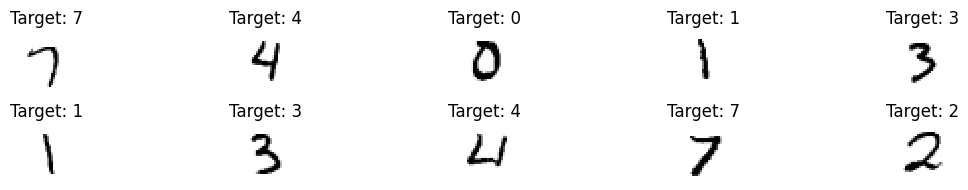

In [4]:
plot_ten_examples(X[25:35,:],Y[25:35])

# 2. Definition of the novelty detection tasks

We are starting with a binary classification problem with **digits of classes 1 and 7**. For this purpose, the following cell constructs some arrays that will help us simulate the novelty detection scenarios:
- `inlier_class_images`: all the images of 1s and 7s
- `outlier_images`: all the images of 0s (you can try to use a different digit as outlier)

In [5]:
# classes of 7 vs 8
inlier_class_images = np.where((Y == 7) | (Y == 1))[0]
inlier_class = np.unique(Y[inlier_class_images])
#outlier class
outlier_images = np.where(Y==0)[0]

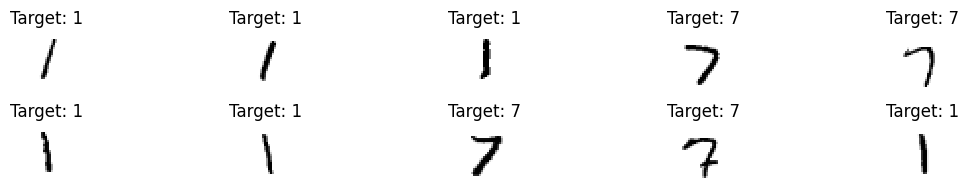

In [6]:
plot_ten_examples(X[inlier_class_images[:10],:],Y[inlier_class_images[:10]])

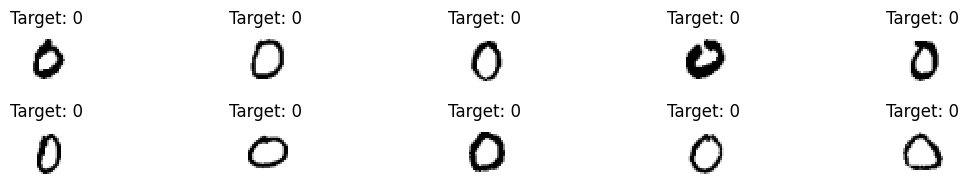

In [7]:
plot_ten_examples(X[outlier_images[:10],:],Y[outlier_images[:10]])

# 3. Standard classification task (without outliers)

The first step is to create a classification scenario only with digits **1** and **7**. For this purpose next cell code:
- Store all the images contained in the list `inlier_class_images` in a numpy array called `X_inlier`.
- Store the true targets of the images contained in the list `inlier_class_images` in a numpy array called `Y_inlier`.
- Split these images in a 80/20 training/testing partition and store these partitions in arrays `X_inlier_train`, `X_inlier_test`, `Y_inlier_train` and `Y_inlier_test`


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_inlier =  X[inlier_class_images, :]
Y_inlier =  Y[inlier_class_images]
X_inlier_train_nosc, X_inlier_test_nosc, Y_inlier_train, Y_inlier_test = train_test_split(X_inlier,
                                                                                Y_inlier,train_size=0.8)

scaler = StandardScaler()
X_inlier_train = scaler.fit_transform(X_inlier_train_nosc)
X_inlier_test = scaler.transform(X_inlier_test_nosc)

print("Size of the training set {0:d}".format(X_inlier_train.shape[0]))
print("Size of the test set {0:d}".format(X_inlier_test.shape[0]))

Size of the training set 1729
Size of the test set 433


## 3.1. First classification method: SVM

The first classification method is a SVM acting on the raw images after their standard normalization. Train a SVM with linear kernel (also use cross validation to tune $C$).

Print the best parameters found for this classifier and its classification accuracy estimated with cross validation (that is, the crossvalidation accuracy achieved by the best set of hyperparameters). Next, use the SVM with its best hyperparameter configuration to compute the accuracy in the test data of the inlier classes (`X_inlier_test` and `Y_inlier_test`)

In [9]:
############
# YOUR CODE
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

v_C = [1e-3, 0.01, 0.1, 1, 100, 1000]

parameters_svm = {'C':v_C}

sc_svm = svm.SVC(kernel='linear')
grid_svm = GridSearchCV(sc_svm , parameters_svm)
grid_svm.fit(X_inlier_train, Y_inlier_train)
print("Best parameters SVM")
print(grid_svm.best_params_)
print("Best CV score SVM")
print(grid_svm.best_score_)


acc_test_inliers_svm = 100.*grid_svm.score(X_inlier_test, Y_inlier_test)
print("Test accuracy, just inlier classes: {0:.2f}".format(acc_test_inliers_svm))

############


Best parameters SVM
{'C': 0.01}
Best CV score SVM
0.9884326045069949
Test accuracy, just inlier classes: 99.77


## 3.2. Second Classification method: PCA + SVM

The second classification method is a pipeline with two steps:
1. PCA with 2 components
2. SVM with linear kernel

Find the best pipeline using cross-validation to optimize the $C$ of the SVM

Print the best parameters found for this classifier (SVM configuration) and its classification accuracy estimated with cross validation (that is, the crossvalidation accuracy achieved by the best set of hyperparameters), as well as their test accuracy.

In [10]:
############
# YOUR CODE

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer


v_C = [0.01, 0.1, 1, 10]
sc_pca_svm = Pipeline([('pca', PCA(n_components=2)),
                      ('svm', svm.SVC(kernel='linear'))])
parameters_sc_pca_svm = {'svm__C':v_C}

grid_sc_pca_svm = GridSearchCV(sc_pca_svm, parameters_sc_pca_svm)

grid_sc_pca_svm.fit(X_inlier_train, Y_inlier_train)
print("Best parameters PCA+SVM")
print(grid_sc_pca_svm.best_params_)
print("Best CV score PCA+SVM")
print(grid_sc_pca_svm.best_score_)
acc_test_inliers_pca_svm = 100.*grid_sc_pca_svm.score(X_inlier_test, Y_inlier_test)
print("Test accuracy, just inlier classes: {0:.2f}".format(acc_test_inliers_pca_svm))
############

Best parameters PCA+SVM
{'svm__C': 0.01}
Best CV score PCA+SVM
0.9705051520482533
Test accuracy, just inlier classes: 97.92


## 3.3. Discussion

Comment on the different test accuracies of the two classification methods. Do you think these classification tasks are easy to solve with machine learning?

**COMMENT:** Notice how using PCA with just 2 components is able to project the data into an space that makes it a theoretically easily separable problem.

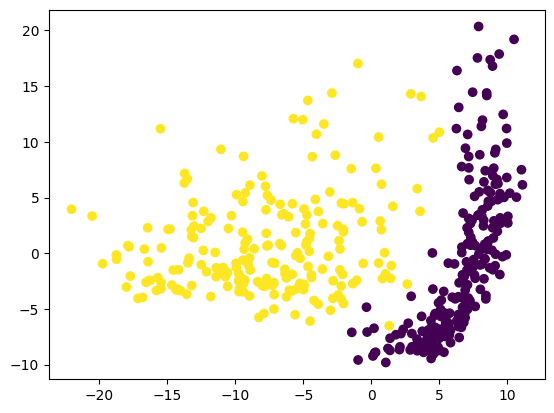

In [11]:
pca = grid_sc_pca_svm.best_estimator_.steps[0][1]
P_inlier_test = pca.transform(X_inlier_test)

import matplotlib.pyplot as plt
plt.scatter(P_inlier_test[:,0], P_inlier_test[:,1], c=Y_inlier_test)
plt.show()

Looking at the plot one could realise that using a non-linear classifier might be more addecuate to classifiy 0s from 7s after the PCA transformation.

In [12]:
############
# YOUR CODE

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer


v_C = np.logspace(-3, 3, 7)
v_gamma = np.logspace(-3, 3, 7)/np.sqrt(X_inlier_train.shape[1])
sc_pca_svm = Pipeline([('pca', PCA(n_components=2)),
                      ('svm', svm.SVC(kernel='rbf'))])
parameters_sc_pca_svm = {'svm__C':v_C, 'svm__gamma': v_gamma}

grid_sc_pca_svm = GridSearchCV(sc_pca_svm, parameters_sc_pca_svm)

grid_sc_pca_svm.fit(X_inlier_train, Y_inlier_train)
print("Best parameters PCA+SVM")
print(grid_sc_pca_svm.best_params_)
print("Best CV score PCA+SVM")
print(grid_sc_pca_svm.best_score_)
acc_test_inliers_pca_svm = 100.*grid_sc_pca_svm.score(X_inlier_test, Y_inlier_test)
print("Test accuracy, just inlier classes: {0:.2f}".format(acc_test_inliers_pca_svm))
############

Best parameters PCA+SVM
{'svm__C': np.float64(100.0), 'svm__gamma': np.float64(0.0035714285714285718)}
Best CV score PCA+SVM
0.9878528943620676
Test accuracy, just inlier classes: 99.08


# 4. Degradation in performance due to novelties

Now you are going to introduce elements of the outlier classes in the **test set** and measure the effect in the performance of the algorithm.  The simulation basically consists in:
- creating a new test set by merging the images in `X_inlier_test` and the outliers determined in each case. Notice **there will be labels in the test set that were not in the training set**.
- naming `my_Xtest` and `my_Ytest` the resulting arrays with the images and the targets, respectively.



## 4.1. Degradation with images of 0s

In this section `my_Xtest` and `my_Ytest` will also incorporate images of **0**s. Next code generates these two arrays.

In [13]:
my_Xtest_nosc = np.vstack((X_inlier_test_nosc, X[outlier_images,:]))
my_Xtest = scaler.transform(my_Xtest_nosc)

my_Ytest = np.hstack((Y_inlier_test, Y[outlier_images]))

The next variable is a list of dicitionaries to store partial results to carry out a final analysis of the results

In [14]:
overall_results_list_dd = []

Now you will simulate the novelties in the test set impact in the classifier performances. Since those novel images belong to classes not present during training, we are going to use [confusion matrices](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) for a systematic collection of the multiclass errors.

Thus, next code provides a function to make predictions with a trained model ('estimator') over a given test set (`my_Xtest`, `my_Ytest`) and evaluate the number of hits and the number of the two sources of error for every individual class in the training set, to check if all the classes are equally contaminated by the outliers or not. With this information, the function biulds a dictionary with the following keys:
- `method`: a tag for describing the classifier, for instance "SVC"
- `hits`: number of elements in the test set correctly assigned to its true class
- `inlier errors`: number of elements in the test set whose true class was present in the training set, but have been incorrectly assigned by the classifier to a wrong class
- `outlier errors`: number of outliers in the test set incorrectly assigned


Additionally, you can plot examples of the photos of the true class and of some of the outliers assigned to that class to discuss any possible interpretability of the outcome.

In [15]:
from sklearn.metrics import confusion_matrix

def simulate(estimator, tag, my_Xtest, my_Ytest):
    predict = estimator.predict(my_Xtest)
    CF = pd.DataFrame(confusion_matrix(my_Ytest, predict, labels=range(40)),
                      index=range(40),
                      columns=range(40))
    dd = {'method':tag,
     'hits':0,
      'inlier errors':0,
      'outlier errors':0}

    all_assigned = CF.sum(0)

    for data in inlier_class:
        print('Digit {0:d}'.format(data))

        assigned = all_assigned.loc[data]
        own_images = CF.loc[data, data]
        inliers = CF.loc[inlier_class, data].sum() - own_images
        outliers = assigned - inliers - own_images
        print("{0:d}s predicted as {0:d}s:       {1:d}\n{2:d}s predicted as {0:d}s:       {3:d}\nOutliers predicted as {0:d}s: {4:d}".format(data, own_images, np.setdiff1d(inlier_class, data)[0], inliers, outliers))
        dd['hits'] += own_images
        dd['inlier errors'] += inliers
        dd['outlier errors'] += outliers
    return dd

Here, you have an example of the use of this function with the previous models using the inlier test data, as well as the resulting dictionaries are saved in the overall result variable:

In [16]:
my_dict = simulate(grid_svm, 'SVM_inlier', X_inlier_test, Y_inlier_test)
overall_results_list_dd.append(my_dict)

Digit 1
1s predicted as 1s:       225
7s predicted as 1s:       1
Outliers predicted as 1s: 0
Digit 7
7s predicted as 7s:       207
1s predicted as 7s:       0
Outliers predicted as 7s: 0


In [17]:
my_dict = simulate(grid_sc_pca_svm, 'PCA_SVM_inlier', X_inlier_test, Y_inlier_test)
overall_results_list_dd.append(my_dict)

Digit 1
1s predicted as 1s:       222
7s predicted as 1s:       1
Outliers predicted as 1s: 0
Digit 7
7s predicted as 7s:       207
1s predicted as 7s:       3
Outliers predicted as 7s: 0


### 4.1.1. Impact of outliers in SVM

Now, using the `simulate()`function, evaluate the performance of the SVM classifier using the merged test set (`my_Xtest`,`my_Ytest`) and save the results to `overall_results_list_dd`.

In [18]:
overall_results_list_dd.append(simulate(grid_svm, 'SVM', my_Xtest, my_Ytest))

Digit 1
1s predicted as 1s:       225
7s predicted as 1s:       1
Outliers predicted as 1s: 7
Digit 7
7s predicted as 7s:       207
1s predicted as 7s:       0
Outliers predicted as 7s: 973


### 4.1.2. Impact on PCA+SVM

Repeat section 4.4.1 for the second classification method

In [19]:
############
# YOUR CODE
overall_results_list_dd.append(simulate(grid_sc_pca_svm, 'PCA + SVM', my_Xtest, my_Ytest))
############

Digit 1
1s predicted as 1s:       222
7s predicted as 1s:       1
Outliers predicted as 1s: 34
Digit 7
7s predicted as 7s:       207
1s predicted as 7s:       3
Outliers predicted as 7s: 946


### 4.1.3. Discussion

Discuss about how the introduction of novelties/outliers affects the performance of the metods. Besides, discuss how the novelties/outliers affect particular classes with each classification method

# 5. Novelty detection

In this section you will design a novelty detection system that helps detect the outliers of the test data before being evaluated by the classifiers. You will be using One Class SVM as core engine of different versions of the novelty detection + classification scheme and decide which option is better.

## 5.1. Novelty detection in raw input data

Use one-class SVM as a preprocessing stage, filtering out samples that will not be processed by the classification.

Write code that
- Train a One Class SVM with `X_inlier_train`; don't forget to normalize the data.
- Print the False Negatives rate that this model achieves in the training data, and tune the value of hyperparameters `gamma`and `nu` until you are comfortable with that False Negatives rate.
- Apply the One Class SVM to the test set with outliers and create a filtered test set including only those test samples that were accepted by the One Class SVM as inliers. Name `filtered_Xtest` and `filtered_Ytest` the arrays containing the filtered test.

Print the size of the original and filtered test sets.

In [20]:
############
# YOUR CODE



############

### 5.1.1. Impact on SVM

Repeat section 4.4.1 but with the filtered test data. Do not forget to include a reference  "One Class SVM" somewhere in the tag for the dictionary.

In [21]:
############
# YOUR CODE

############

### 5.1.2. Impact on PCA+SVM
Repeat section 5.1.1 with the second classification method

In [22]:
############
# YOUR CODE

############

## 5.2. Novelty detection in the transformed space

In the 2nd method there is another chance to detect outliers, and it is in the transformed space resulting from the application of the feature extraction.

Apply the One Class SVM filter after the PCA. For this purpose you need to implement a secondary pipeline with the already trained PCA step (the transformation) of the pipeline `pca_svm`.

Write code that:
- Implements that secondary pipeline to get the transformed data in input space
- Get the transformed training data, in an array `X_pca_train`
- Train a One Class SVM with `X_pca_train`
- Print the False Negatives Rates of this One Class SVM in the set `X_pca_train`
- Tune the value of hyperparameter `nu` until you are comfortable with this False Negatives rate.
- Transform `my_XTest` with the PCA
- Apply the One Class SVM to this transformed test set
- Feed the already trained first classifier with the filtered test set and create the dictionary with the results
- Store this dictionary in `overall_results_list_dd`

In [23]:
############
# YOUR CODE

############

# 6. Overall results
Create a dataframe with `overall_results_list_dd` and print the performances of all the methods. Discuss the advantages of each of the novelty detection strategies evaluated for each main classifier.

**COMMENTS**: Including the OCSVM clearly improves the performance of the two schemes (SVM or PCA+SVM), by removing outliers before training the model we improve the classification of inliers and reduce outliers. The results of 4 and 5 are better than those of 2 and 3, altough some outliers are not detected.

Applying the OCSVM after the PCA does not contribute much, it is possible that the PCA (by reducing the dimensionality) prevents detecting the outliers well and the OCSVM does nothing. The results of 6 are almost identical to those of 3.

We can visualise this with PCA if we plot which samples have been identified as outliers.